# Day 2 hands-on: generative models

This exercise builds on the generative-models tutorial of the ML4FP school and on the normalizing-flow exercise by T. Quadfasel, M. Sommerhalder and S. Diefenbacher, https://github.com/uhh-pd-ml/flow-exercise

In the lecture we saw two ways to learn a density $p_\text{data}(x)$ from samples and generate new samples from it. In this session we
1. train a **normalizing flow**, which maps data to a Gaussian and back and gives us the density $p_\text{model}(x)$;
2. train a **diffusion model**, which learns to remove noise step by step;
3. give the flow a **condition**, which moon an event belongs to, and generate the two moons separately;
4. (bonus) use a conditional flow for the two classes, $p(x|S)$ and $p(x|B)$, and turn it into a **likelihood-ratio classifier** like on Day 1.

**Colab:** everything runs on the CPU in well under a minute per training, no GPU runtime needed. Run the cells from top to bottom with `Shift+Enter`.

In [ ]:
# nflows is not pre-installed on Colab
!pip install -q nflows

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from nflows.flows.base import Flow                                        # container: transformations + latent distribution
from nflows.distributions.normal import StandardNormal                    # Gaussian latent space
from nflows.transforms.base import CompositeTransform                     # chains several transformations
from nflows.transforms.autoregressive import MaskedAffineAutoregressiveTransform   # affine transformation, like the coupling layers
from nflows.transforms.permutations import ReversePermutation             # swaps the order of the features

torch.manual_seed(42)
np.random.seed(42)

## 1) The two-moons dataset

We use the two moons from Day 1, now without labels and with less noise, so that the generative models have a sharp structure to reproduce. We standardize the data to mean zero and unit width, the same scale as the Gaussian latent space.

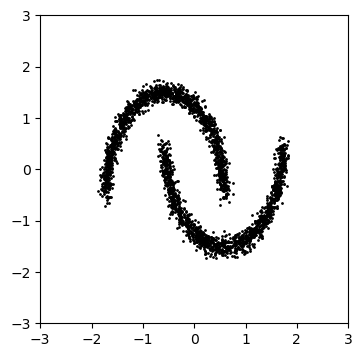

In [3]:
def get_moons(n, noise, seed):
    x, y = make_moons(n_samples=n, noise=noise, random_state=seed)
    x = (x - np.array([0.5, 0.25])) / np.array([0.87, 0.5])     # roughly mean 0, width 1
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

x_data, _ = get_moons(10000, noise=0.05, seed=0)
data_loader = DataLoader(TensorDataset(x_data), batch_size=256, shuffle=True)


def plot_samples(samples, title="generated", data=x_data):
    fig, axes = plt.subplots(1, 2, figsize=(9, 4))
    for ax, points, name, color in [(axes[0], data, "data", "black"), (axes[1], samples, title, "darkblue")]:
        ax.plot(points[:, 0], points[:, 1], ".", color=color, ms=2)
        ax.set_title(name)
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
    plt.show()

plt.figure(figsize=(4.5, 4))
plt.plot(x_data[:3000, 0], x_data[:3000, 1], ".", color="black", ms=2)
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.gca().set_aspect("equal")
plt.show()

## 2) Normalizing flows

A normalizing flow is an invertible network $\overline{G}_\theta$ which maps a data point $x$ to a latent point $r$, where we choose a standard Gaussian $p_\text{latent}(r)$. From the change of variables formula, the model density is
$$p_\text{model}(x) = p_\text{latent}\big(\overline{G}_\theta(x)\big) \left| \frac{\partial \overline{G}_\theta(x)}{\partial x} \right| \; ,$$
and we train with the negative log-likelihood $\mathcal{L} = -\langle \log p_\text{model}(x) \rangle_{p_\text{data}}$. To generate, we draw $r$ from the Gaussian and run the network backwards.

We use the `nflows` package. Its transformation `MaskedAffineAutoregressiveTransform` is an affine transformation $x \to x \, e^{s} + t$ with small networks $s$ and $t$, like the coupling layers of the lecture, with a triangular Jacobian. Between the transformations we swap the two features, so that each one gets transformed. `flow.log_prob(x)` returns $\log p_\text{model}(x)$, `flow.sample(n)` generates.

In [4]:
def make_flow(n_layers, hidden_features, context_features=None):
    transforms = []
    for i in range(n_layers):
        transforms.append(MaskedAffineAutoregressiveTransform(features=2, hidden_features=hidden_features,
                                                              context_features=context_features))
        transforms.append(ReversePermutation(features=2))
    return Flow(CompositeTransform(transforms), StandardNormal(shape=[2]))


def train_flow(flow, loader, n_epochs, lr=1e-3):
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    for epoch in range(n_epochs):
        total, n = 0.0, 0
        for batch in loader:
            x = batch[0]
            context = batch[1][:, None] if len(batch) > 1 else None     # used for conditional flows in part 4
            loss = -flow.log_prob(x, context=context).mean()            # negative log-likelihood
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total, n = total + loss.item() * len(x), n + len(x)
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}   NLL {total / n:.3f}")

**Task:** run the two cells below. The flow is functional, but far from optimal. Then modify the marked parameters to improve the generated samples. Look at all three plots: the generated samples, the data mapped to the latent space (which should look like a Gaussian), and the learned density.

In [5]:
########################################
### Modify network parameters here ###
n_layers = 5
hidden_features = 32
n_epochs = 30
########################################

flow = make_flow(n_layers, hidden_features)
train_flow(flow, data_loader, n_epochs)

epoch   0   NLL 3.476


epoch  10   NLL 1.603


epoch  20   NLL 1.488


epoch  29   NLL 1.238


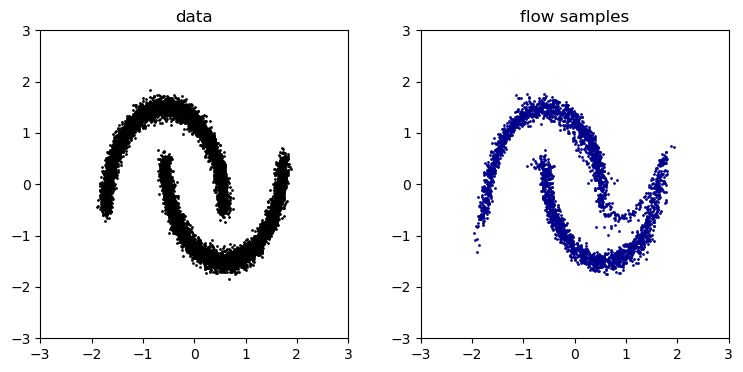

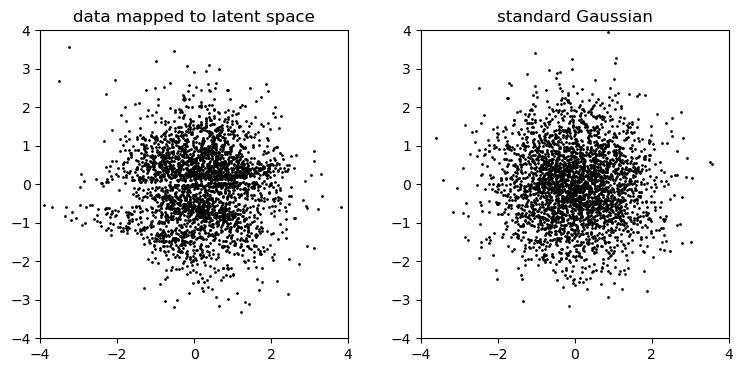

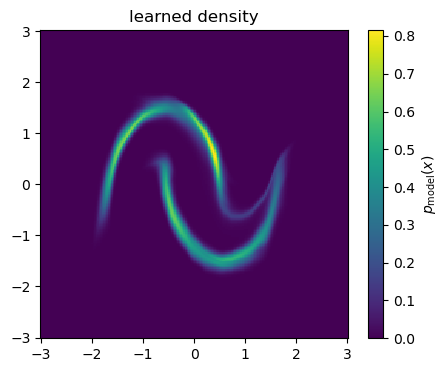

In [6]:
with torch.no_grad():
    samples = flow.sample(3000)
    latent = flow.transform_to_noise(x_data[:3000])       # data -> latent direction
plot_samples(samples, title="flow samples")

# the data mapped to the latent space should look like a standard Gaussian
r = torch.randn(3000, 2)
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, points, name in [(axes[0], latent, "data mapped to latent space"), (axes[1], r, "standard Gaussian")]:
    ax.plot(points[:, 0], points[:, 1], ".", color="black", ms=2)
    ax.set_title(name)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
plt.show()

# the flow is a density estimator: evaluate p_model(x) on a grid
x1, x2 = torch.meshgrid(torch.linspace(-3, 3, 200), torch.linspace(-3, 3, 200), indexing="xy")
grid = torch.stack([x1.flatten(), x2.flatten()], dim=1)
with torch.no_grad():
    density = flow.log_prob(grid).exp().reshape(x1.shape)
plt.figure(figsize=(5, 4))
plt.pcolormesh(x1, x2, density, cmap="viridis", shading="auto")
plt.colorbar(label="$p_\\mathrm{model}(x)$")
plt.title("learned density")
plt.gca().set_aspect("equal")
plt.show()

**Solution notes:** a single affine layer can only shift, stretch and slightly bend the Gaussian, so the samples are a smeared blob and the mapped data is far from Gaussian. With several layers the flow separates the two moons; the remaining artefacts are thin bridges between the moons, because an invertible map from one connected Gaussian has to keep the density connected.

The flow is a chain of transformations. The cell below starts from Gaussian samples and applies the transformations one by one, so we can watch the Gaussian being deformed into the two moons. Nothing to do here, just look.

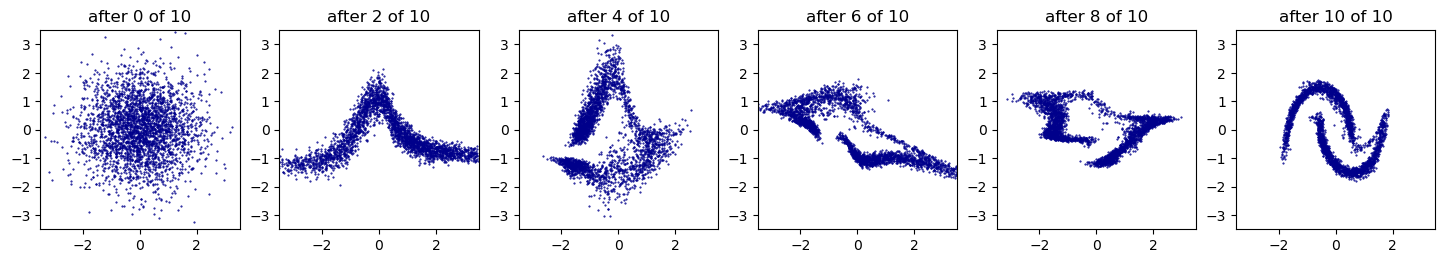

In [7]:
transforms = flow._transform._transforms          # the list of transformations, data -> latent order
n_steps = len(transforms)
show = sorted(set(np.linspace(0, n_steps, 6).astype(int)))

z = torch.randn(3000, 2)
fig, axes = plt.subplots(1, len(show), figsize=(3 * len(show), 3))
with torch.no_grad():
    for k in range(n_steps + 1):
        if k in show:
            ax = axes[show.index(k)]
            ax.plot(z[:, 0], z[:, 1], ".", color="darkblue", ms=1)
            ax.set_title(f"after {k} of {n_steps}")
            ax.set_xlim(-3.5, 3.5)
            ax.set_ylim(-3.5, 3.5)
            ax.set_aspect("equal")
        if k < n_steps:
            z, _ = transforms[-(k + 1)].inverse(z)   # generation runs the transformations backwards
plt.show()

## 3) Diffusion models

Now we learn the same distribution with a diffusion model (DDPM). The forward direction adds noise in $T$ small steps with variances $\beta_t$. With $\alpha_t = 1-\beta_t$ and $\bar\alpha_t = \prod_{s \le t} \alpha_s$ we can jump to any step directly,
$$x_t = \sqrt{\bar\alpha_t}\, x_0 + \sqrt{1-\bar\alpha_t}\, \epsilon \qquad \text{with} \quad \epsilon \sim \mathcal{N}(0,1) \; .$$
A network $\epsilon_\theta(x_t, t)$ learns to predict the added noise with an MSE loss. To generate, we start from pure noise and remove the predicted noise step by step.

**Task:** complete the function `add_noise` with the formula above. The plot below then shows the forward process on our data, like the figure in the lecture.

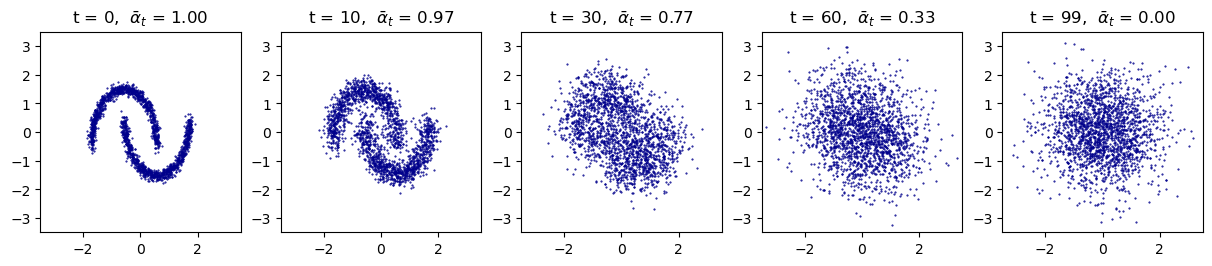

In [8]:
def make_schedule(T, kind="linear"):
    if kind == "linear":
        beta = torch.linspace(1e-4, 0.1, T)
    elif kind == "cosine":                 # adds noise more slowly at the start and the end
        s = 0.008
        steps = torch.arange(T + 1) / T
        f = torch.cos((steps + s) / (1 + s) * math.pi / 2)**2
        alpha_bar = f / f[0]
        beta = (1 - alpha_bar[1:] / alpha_bar[:-1]).clamp(max=0.999)
    alpha = 1 - beta
    alpha_bar = torch.cumprod(alpha, dim=0)
    return beta, alpha, alpha_bar


def add_noise(x0, eps, alpha_bar_t):
    ########################################
    ### Implement the forward process here ###
    xt = alpha_bar_t.sqrt() * x0 + (1 - alpha_bar_t).sqrt() * eps
    ########################################
    return xt


T = 100
beta, alpha, alpha_bar = make_schedule(T, "cosine")
x0 = x_data[:2000]
eps = torch.randn_like(x0)
show = [0, 10, 30, 60, 99]
fig, axes = plt.subplots(1, len(show), figsize=(3 * len(show), 3))
for ax, t in zip(axes, show):
    xt = add_noise(x0, eps, alpha_bar[t])
    ax.plot(xt[:, 0], xt[:, 1], ".", color="darkblue", ms=1)
    ax.set_title(f"t = {t},  $\\bar\\alpha_t$ = {alpha_bar[t]:.2f}")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect("equal")
plt.show()

The network needs to know the time step. A single number $t$ is hard to use for a network, so we encode it with sines and cosines of different frequencies, the same trick as the positional encoding of transformers on Day 3. The denoiser is a plain dense network with the noisy point and the time encoding as input and the predicted noise as output.

In [9]:
def time_embedding(t, dim=16):
    half = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half) / (half - 1))
    angles = t[:, None].float() * freqs[None, :]
    return torch.cat([angles.sin(), angles.cos()], dim=-1)


class Denoiser(nn.Module):
    def __init__(self, n_hidden=128, t_dim=16):
        super().__init__()
        self.t_dim = t_dim
        self.layer1 = nn.Linear(2 + t_dim, n_hidden)
        self.layer2 = nn.Linear(n_hidden, n_hidden)
        self.layer3 = nn.Linear(n_hidden, n_hidden)
        self.layer4 = nn.Linear(n_hidden, 2)

    def forward(self, xt, t):
        x = torch.cat([xt, time_embedding(t, self.t_dim)], dim=-1)
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        x = torch.relu(self.layer3(x))
        return self.layer4(x)                  # predicted noise, same shape as x


def train_diffusion(model, loader, alpha_bar, n_epochs, lr=1e-3):
    T = len(alpha_bar)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(n_epochs):
        total, n = 0.0, 0
        for (x0,) in loader:
            t = torch.randint(0, T, (len(x0),))              # a random time step for every event
            eps = torch.randn_like(x0)
            xt = add_noise(x0, eps, alpha_bar[t][:, None])
            loss = ((model(xt, t) - eps)**2).mean()          # MSE between true and predicted noise
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total, n = total + loss.item() * len(x0), n + len(x0)
        if epoch % 20 == 0 or epoch == n_epochs - 1:
            print(f"epoch {epoch:3d}   loss {total / n:.3f}")


@torch.no_grad()
def sample_diffusion(model, beta, alpha, alpha_bar, n=3000, keep=()):
    T = len(beta)
    x = torch.randn(n, 2)                                    # start from pure noise
    snapshots = {}
    for t in range(T - 1, -1, -1):
        eps_pred = model(x, torch.full((n,), t))
        z = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (x - beta[t] / (1 - alpha_bar[t]).sqrt() * eps_pred) / alpha[t].sqrt() + beta[t].sqrt() * z
        if t in keep:
            snapshots[t] = x.clone()
    return x, snapshots

**Task:** train the diffusion model and look at the generated samples and at the generation step by step. The default settings are poor. Improve them: the number of time steps $T$, the shape of the noise schedule, the number of epochs.

epoch   0   loss 0.708


epoch  20   loss 0.429


epoch  40   loss 0.420


epoch  60   loss 0.420


epoch  80   loss 0.409


epoch  99   loss 0.410


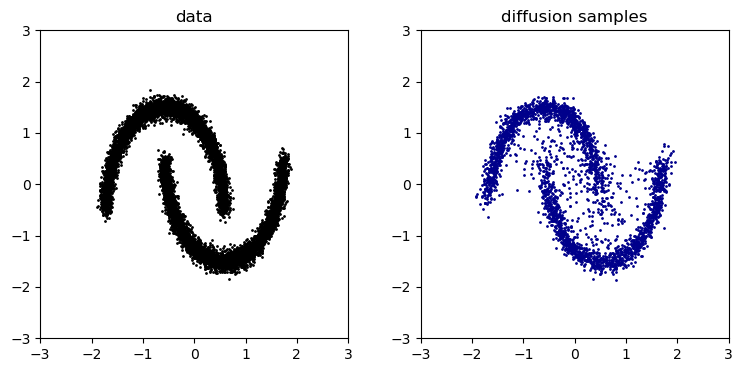

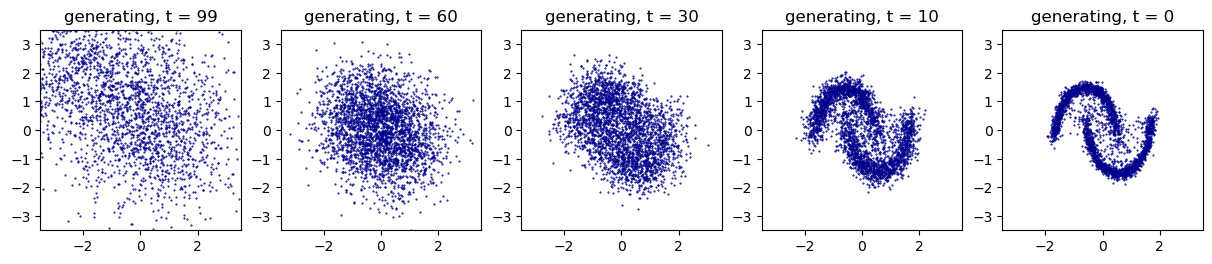

In [10]:
########################################
### Modify diffusion parameters here ###
T = 100
schedule = "cosine"      # "linear" or "cosine"
n_epochs = 100
########################################

beta, alpha, alpha_bar = make_schedule(T, schedule)
denoiser = Denoiser()
train_diffusion(denoiser, data_loader, alpha_bar, n_epochs)

keep = sorted(set([T - 1, int(0.6 * T), int(0.3 * T), int(0.1 * T), 0]), reverse=True)
samples, snapshots = sample_diffusion(denoiser, beta, alpha, alpha_bar, keep=keep)
plot_samples(samples, title="diffusion samples")

fig, axes = plt.subplots(1, len(keep), figsize=(3 * len(keep), 3))
for ax, t in zip(axes, keep):
    ax.plot(snapshots[t][:, 0], snapshots[t][:, 1], ".", color="darkblue", ms=1)
    ax.set_title(f"generating, t = {t}")
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect("equal")
plt.show()

**Solution notes:** with $T=10$ and a linear schedule ending at $\beta = 0.1$, the last step still has $\bar\alpha_T \approx 0.6$, so the forward process never reaches pure noise, and the generation starts from the wrong distribution. More steps and a schedule that ends at $\bar\alpha_T \approx 0$ fix this; the cosine schedule adds noise slowly at the beginning, where the fine structure of the moons is destroyed. A few percent of the generated points still land between the moons. Longer training or more steps barely change this; like the thin bridges of the flow, these are the regions where the model has to interpolate.

In the lecture we said that the network learns the *average* noise over all data points that could have produced a noisy point, which turns into a best guess
$$\hat x_0 = \frac{x_t - \sqrt{1-\bar\alpha_t}\, \epsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}} \; .$$
The cell below shows this best guess for the same noisy points at different noise levels. Nothing to do here, just look: at large $t$ the guess is a blurry average, at small $t$ it is sharp.

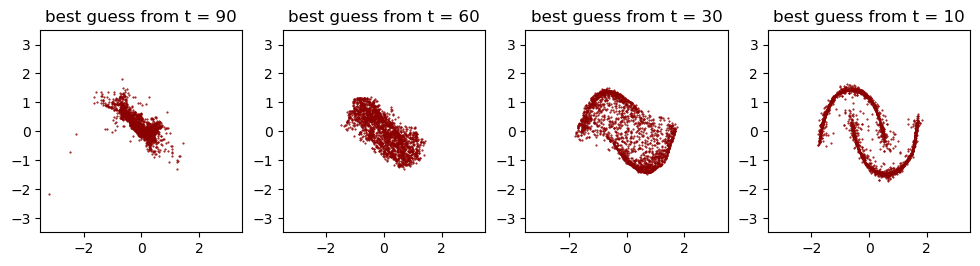

In [11]:
x0 = x_data[:2000]
eps = torch.randn_like(x0)
show = [int(0.9 * T), int(0.6 * T), int(0.3 * T), int(0.1 * T)]
fig, axes = plt.subplots(1, len(show), figsize=(3 * len(show), 3))
with torch.no_grad():
    for ax, t in zip(axes, show):
        xt = add_noise(x0, eps, alpha_bar[t])
        eps_pred = denoiser(xt, torch.full((len(xt),), t))
        x0_hat = (xt - (1 - alpha_bar[t]).sqrt() * eps_pred) / alpha_bar[t].sqrt()
        ax.plot(x0_hat[:, 0], x0_hat[:, 1], ".", color="darkred", ms=1)
        ax.set_title(f"best guess from t = {t}")
        ax.set_xlim(-3.5, 3.5)
        ax.set_ylim(-3.5, 3.5)
        ax.set_aspect("equal")
plt.show()

## 4) Conditional generation

In the lecture we saw conditional generative networks, which learn $p_\text{model}(x|c)$ for a given condition $c$. For the two moons the simplest condition is which moon an event belongs to, $c = 0$ for the upper and $c = 1$ for the lower moon. The flow gets the condition as `context`: it is passed to the small networks $s$ and $t$ inside every transformation, but it is not transformed itself. The loss is the same negative log-likelihood as before, now $-\langle \log p_\text{model}(x|c) \rangle$. Our `train_flow` already passes the second entry of each batch as the condition.

epoch   0   NLL 2.889


epoch  10   NLL 0.546


epoch  20   NLL 0.474


epoch  29   NLL 0.488


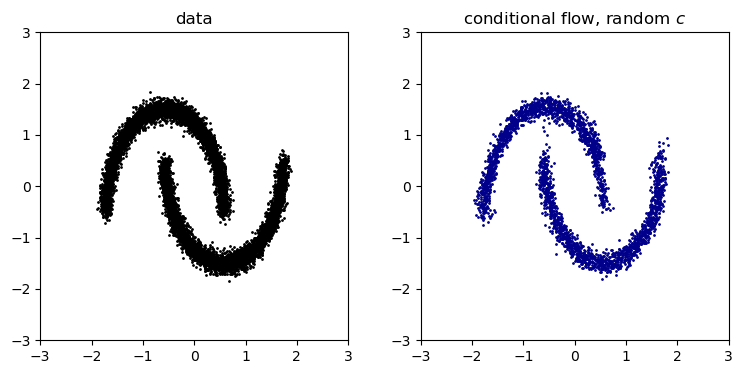

In [12]:
x_labelled, c_labelled = get_moons(10000, noise=0.05, seed=0)      # the same events as x_data, now with the moon label
moon_loader = DataLoader(TensorDataset(x_labelled, c_labelled), batch_size=256, shuffle=True)

flow_moons = make_flow(n_layers=5, hidden_features=32, context_features=1)
train_flow(flow_moons, moon_loader, n_epochs=30)

# generating with random conditions reproduces the full two moons
with torch.no_grad():
    c_random = torch.randint(0, 2, (3000, 1)).float()
    samples = flow_moons.sample(1, context=c_random).squeeze(1)    # one event per row of the condition
plot_samples(samples, title="conditional flow, random $c$")

**Task:** generate events from the upper moon ($c=0$) and from the lower moon ($c=1$) separately, and plot them in two colours. `flow_moons.sample(1, context=c)` returns one event for each row of a condition tensor `c` of shape `(n, 1)`.

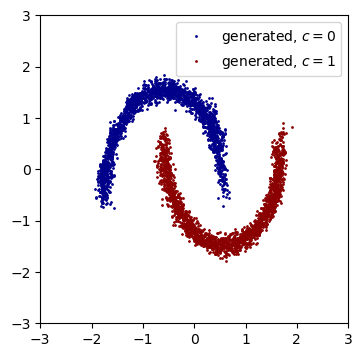

In [13]:
n = 2000
with torch.no_grad():
    ########################################
    ### Generate the two moons here ###
    samples_0 = flow_moons.sample(1, context=torch.zeros(n, 1)).squeeze(1)
    samples_1 = flow_moons.sample(1, context=torch.ones(n, 1)).squeeze(1)
    ########################################

plt.figure(figsize=(5, 4))
plt.plot(samples_0[:, 0], samples_0[:, 1], ".", color="darkblue", ms=2, label="generated, $c=0$")
plt.plot(samples_1[:, 0], samples_1[:, 1], ".", color="darkred", ms=2, label="generated, $c=1$")
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.gca().set_aspect("equal")
plt.show()

**Task:** the flow was only trained with $c = 0$ and $c = 1$, but nothing stops us from giving it other values. Generate events for the conditions in the cell below, for instance $c = 0.5$ halfway between the two moons, or $c = 2$ outside the training range. What do you see, and would you trust these events?

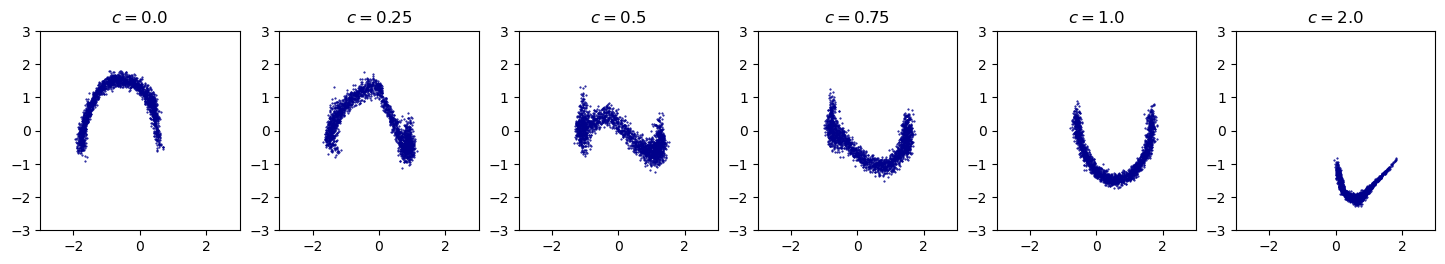

In [14]:
########################################
### Choose the conditions here ###
c_values = [0.0, 0.25, 0.5, 0.75, 1.0, 2.0]
########################################

fig, axes = plt.subplots(1, len(c_values), figsize=(3 * len(c_values), 3))
with torch.no_grad():
    for ax, c in zip(axes, c_values):
        samples_c = flow_moons.sample(1, context=torch.full((2000, 1), c)).squeeze(1)
        ax.plot(samples_c[:, 0], samples_c[:, 1], ".", color="darkblue", ms=1)
        ax.set_title(f"$c = {c}$")
        ax.set_xlim(-3, 3)
        ax.set_ylim(-3, 3)
        ax.set_aspect("equal")
plt.show()

**Solution notes:** with $c=0$ and $c=1$ the flow generates the upper and the lower moon cleanly, and with random conditions the full dataset. For conditions in between, it morphs one moon continuously into the other; at $c = 0.5$ we get an S-shaped curve which appears nowhere in the training data. The network is a smooth function of $c$, so it interpolates, but the training never told it what should happen between the moons, and here there is no right answer. For $c = 2$, outside the training range, it extrapolates into a distorted shape. A conditional generative network is only reliable for conditions covered by the training data, densely enough for continuous conditions like the energy of a particle. It is the same lesson as for the classifier far away from the data on Day 1.

## 5) Bonus: flows as likelihood-ratio classifiers

In section 4 the condition was which moon an event belongs to. If we use the labels of Day 1 instead, signal ($y=1$) and background ($y=0$), the conditional flow gives us both class densities $p(x|S)$ and $p(x|B)$, and on Day 1 we saw that their ratio is the optimal classifier:
$$r(x) = \frac{p(x|S)}{p(x|B)} \qquad \text{and} \qquad C(x) = P(S|x) = \frac{r(x)}{r(x) + 1} \quad \text{for equal priors.}$$
We use the labelled two moons with the larger noise of Day 1, where the classes overlap. The label is passed to the flow as `context`.

In [15]:
x_train, y_train = get_moons(4000, noise=0.2, seed=1)
x_test, y_test = get_moons(1000, noise=0.2, seed=2)
labelled_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=256, shuffle=True)

cond_flow = make_flow(n_layers=5, hidden_features=32, context_features=1)
train_flow(cond_flow, labelled_loader, n_epochs=50)

epoch   0   NLL 3.993


epoch  10   NLL 2.018


epoch  20   NLL 1.905


epoch  30   NLL 1.901


epoch  40   NLL 1.905


epoch  49   NLL 1.885


**Bonus Task:** evaluate both log-likelihoods for the test events, `cond_flow.log_prob(x, context=...)`, and build the classifier output $C(x)$ from them. What accuracy do you get with the cut $C > 0.5$? Compare with the deep classifier from Day 1 (about 97%).

test accuracy of the flow classifier: 0.967


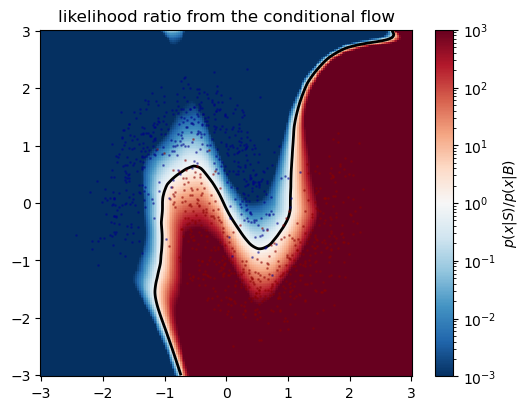

In [16]:
def flow_classifier(x):
    with torch.no_grad():
        log_p_S = cond_flow.log_prob(x, context=torch.ones(len(x), 1))
        log_p_B = cond_flow.log_prob(x, context=torch.zeros(len(x), 1))
    ########################################
    ### Build the classifier here ###
    log_r = log_p_S - log_p_B              # log likelihood ratio
    C = torch.sigmoid(log_r)               # r / (r + 1), numerically stable
    ########################################
    return C, log_r


C_test, _ = flow_classifier(x_test)
accuracy = ((C_test > 0.5).float() == y_test).float().mean().item()
print(f"test accuracy of the flow classifier: {accuracy:.3f}")

# the learned likelihood ratio over the plane, as on Day 1
x1, x2 = torch.meshgrid(torch.linspace(-3, 3, 200), torch.linspace(-3, 3, 200), indexing="xy")
grid = torch.stack([x1.flatten(), x2.flatten()], dim=1)
_, log_r_grid = flow_classifier(grid)
plt.figure(figsize=(6, 4.5))
mesh = plt.pcolormesh(x1, x2, log_r_grid.exp().clip(1e-3, 1e3).reshape(x1.shape),
                      cmap="RdBu_r", norm=LogNorm(1e-3, 1e3), shading="auto")
plt.colorbar(mesh, label="$p(x|S)/p(x|B)$")
plt.contour(x1, x2, log_r_grid.reshape(x1.shape), levels=[0.0], colors="black", linewidths=2)
plt.plot(x_test[y_test == 1, 0], x_test[y_test == 1, 1], ".", color="darkred", ms=2, alpha=0.4)
plt.plot(x_test[y_test == 0, 0], x_test[y_test == 0, 1], ".", color="darkblue", ms=2, alpha=0.4)
plt.title("likelihood ratio from the conditional flow")
plt.show()

**Solution notes:** $C = r/(r+1) = \sigma(\log r)$, the sigmoid of the log-likelihood ratio, which is exactly the output layer of the Day 1 classifier. The flow classifier reaches a similar accuracy, but it takes a detour: it has to learn both full densities, including everything that is irrelevant for the classification, while the Day 1 classifier only learns their ratio. In return the flow can also generate events. Where both densities are tiny, far away from the data, the ratio of two badly known numbers is unreliable, just like for the Day 1 classifier. On Day 3 we will use classifiers to learn such density ratios directly.